### CAN ID Cross-File Validation

The benign EDA was built from a single 10M message file. This notebook checks the 12 files in order to see the matching patterns from the benign analysis. This notebook should provide whether the files share the same CAN ID **vocabulary**, how much more **data** the full set provides for pretraining, whether each CAN ID is **used** the same way across files, and which attacks can be spotted from CAN IDs alone by comparing attacks behaviour with normal behaviour. 

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

BASE = Path("..").resolve()
BENIGN_LOGS = BASE / "Data" / "CAN_MIRGU_Benign_Logs" / "Benign"
ATTACK_DIR = BASE / "Data" / "CAN_MIRGU_Attack_Logs" / "Real_attacks"

sys.path.append(str(BASE / "src"))
from analyse_attack_file import analyse_attack_file
from analyse_benign_file import analyse_benign_file
from load_attack_file import ATTACKS, metadata as attack_metadata

In [2]:
benign_files = sorted(BENIGN_LOGS.rglob("*.log"))
print("Benign files found:", len(benign_files))

Benign files found: 12


### Analysis of the benign files 

In [3]:
benign_results = []
benign_union = set()
benign_intersection = None
summary_rows = []

for benign_file in benign_files:
    file_result = analyse_benign_file(benign_file)
    benign_results.append(file_result)

    file_can_ids = file_result["can_ids"]
    benign_union.update(file_can_ids)

    if benign_intersection is None:
        benign_intersection = file_can_ids.copy()
    else:
        benign_intersection.intersection_update(file_can_ids)

for result in benign_results:
    summary_rows.append({
        "file": result["file"],
        "messages": result["message_count"],
        "unique_ids": len(result["can_ids"]),
        "duration_s": round(result["duration"], 1),
        "messages_per_second": round(result["message_rate"], 1),
    })
    
benign_summary = pd.DataFrame(summary_rows)
benign_summary


,file,messages,unique_ids,duration_s,messages_per_second
0,Benign_day1_file1.log,10000000,56,5281.8,1893.3
1,Benign_day1_file2.log,10000000,56,5337.0,1873.7
2,Benign_day1_file3.log,8494995,56,4574.5,1857.0
3,Benign_day1_file4.log,10000000,56,6547.4,1527.3
4,Benign_day1_file5.log,7000000,56,4044.5,1730.7
5,Benign_day1_file6.log,589705,56,374.1,1576.4
6,Benign_day2_file1.log,10110000,56,5305.1,1905.7
7,Benign_day2_file2.log,10094091,56,5916.0,1706.2
8,Benign_day3_file1.log,9807445,56,5170.9,1896.7
9,Benign_day4_file1.log,9670832,56,6046.7,1599.4


In [4]:
print(f"CAN IDs shared by ALL 12 files (intersection): {len(benign_intersection)}")
print(f"CAN IDs seen in ANY file (union): {len(benign_union)}")
print(f"Vocabulary identical across all files: {benign_intersection == benign_union}")

CAN IDs shared by ALL 12 files (intersection): 56
CAN IDs seen in ANY file (union): 56
Vocabulary identical across all files: True


The table shows that all 12 benign files contain the same 56 IDs, showing that the vehicle's CAN ID vocabulary is stable across the recordings. However, the files vary in duration, number of messages and overall message rate, which ranges from  1,500 to 1,900 messages per second proving normal variation from different driving and recording conditions rather
than anomalies. For the model, the table shows that CAN ID presence is highly consistent, while traffic intensity naturally changes between recordings.

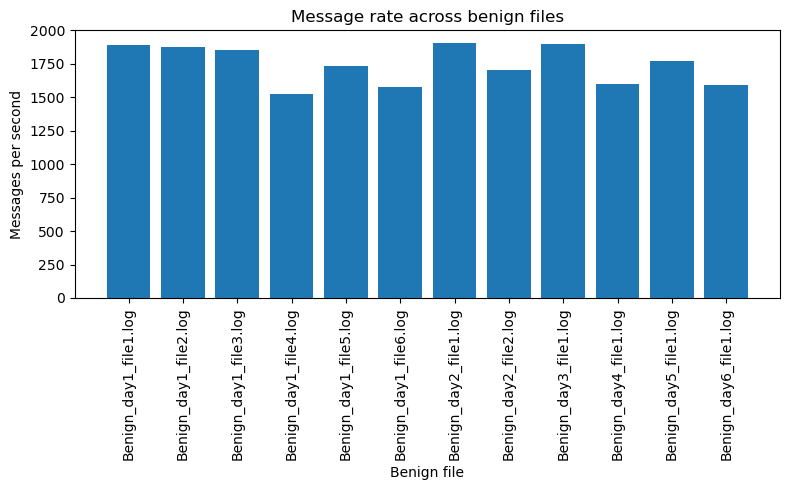

In [5]:
plt.figure(figsize=(8, 5))
plt.bar(benign_summary["file"], benign_summary["messages_per_second"])
plt.xlabel("Benign file")
plt.ylabel("Messages per second")
plt.title("Message rate across benign files")
plt.ylim(bottom=0)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### Data Volume Across Files

The benign EDA used a single ~10M-message file. This shows the full benign data pool across the 12 files, from which the three pretraining files were sampled. 

In [6]:
# 12 files vs the single-file benign baseline used in the EDA
single_file_baseline = 10_000_000   # Benign_day1_file2.log, the file used in the benign EDA
total_messages = 0 
total_duration_hours = 0 
for result in benign_results: 
    total_messages += result["message_count"]
    total_duration_hours += result["duration"] / 3600

print(f"Benign files: {len(benign_results)}")
print(f"Total benign messages: {total_messages:,}")
print(f"Total benign duration: {total_duration_hours:.1f} hours")
print(f"Single-file baseline: {single_file_baseline:,}")
print(f"Volume gain:{total_messages / single_file_baseline:.1f}x more messages")


Benign files: 12
Total benign messages: 106,479,422
Total benign duration: 16.9 hours
Single-file baseline: 10,000,000
Volume gain:10.6x more messages


The 12 files together provide about 106.5 million benign messages over 16.9 hours around 10× a single ~10M message file. That extra volume does not provide a more in depth CAN ID analysis: every file uses the same 56 IDs with similar rates and proportions, so no file is more representative than another. That is why pretraining uses 3 files from different days rather than all twelve, which would cost far more memory. 

#### CAN IDs Message Frequency Across Files

In [7]:
rate_summary_rows = []

for can_id in sorted(benign_union):
    message_rates = []
    
    for file_result in benign_results:
        message_count = file_result["id_counts"][can_id]
        message_rate = message_count / file_result["duration"]
        message_rates.append(message_rate)

    minimum_rate = min(message_rates)
    maximum_rate = max(message_rates)
    change_percentage = ((maximum_rate - minimum_rate) / minimum_rate) * 100

    rate_summary_rows.append({
        "can_id": can_id,
        "min_rate": round(minimum_rate, 2),
        "max_rate": round(maximum_rate, 2),
        "change_percentage": round(change_percentage, 1),
    })

rate_table = pd.DataFrame(rate_summary_rows).sort_values("change_percentage", ascending=False)
rate_table.head(10)


,can_id,min_rate,max_rate,change_percentage
39,52A,6.35,9.08,43.1
54,5E3,0.76,1.00,31.3
28,4A2,1.52,2.00,31.2
15,389,38.09,49.99,31.2
48,593,3.81,5.00,31.2
34,50A,3.81,5.00,31.2
33,507,7.62,10.00,31.2
24,47F,38.12,50.00,31.2
20,420,38.09,49.99,31.2
17,394,38.12,50.00,31.2


Across the benign recordings, the transmission rate of the same CAN IDs is not completely fixed. Most IDs show a relative variation of around 31%. This shows that normal CAN traffic can naturally vary in frequency between recordings, so these changes should not automatically be interpreted as attacks.

In [8]:
attack_names = []
unique_ids = []
new_ids = []

for attack_name in ATTACKS:
    start, end = attack_metadata[attack_name]["injection_interval"]
    file_path = ATTACK_DIR / f"{attack_name}.log"

    attack_data = analyse_attack_file(file_path, start, end)
    attack_ids = attack_data["complete_file_can_ids"]
    
    attack_names.append(attack_name)
    unique_ids.append(len(attack_ids))
    new_ids.append(len(attack_ids - benign_union))

    attack_summary = pd.DataFrame({
        "attack": attack_names,
        "unique_ids": unique_ids,
        "new_ids": new_ids,
    })

attack_summary

,attack,unique_ids,new_ids
0,Steering_angle_attack,56,0
1,Brake_warning_attack,56,0
2,Power_steering_attack,56,0
3,Min_speedometer_attack_1,54,0
4,EMS_replay_attack,56,0
5,Steering_angle_replay,56,0
6,Fuzzing_random_IDs,646,590
7,Fuzzing_valid_IDs,56,0
8,DoS_attack,55,1
